# IRRBB Stress Testing Framework
## Major European G-SIB | ALM Python Portfolio — Project 2

---

### Overview
This notebook implements an **Interest Rate Risk in the Banking Book (IRRBB)** 
Stress Testing Framework, calibrated to the balance sheet of a major European G-SIB.

All figures are in **EUR millions (€m)** unless stated otherwise.

### Regulatory context
Under **Basel BCBS 368 (2016)** and **EBA IRRBB Guidelines**, banks must apply 
six standardised interest rate shock scenarios and report:

- **ΔEVE** — Change in Economic Value of Equity (long-run balance sheet impact)
- **ΔNII** — Change in Net Interest Income (short-run income impact)

If **ΔEVE under any scenario exceeds 15% of Tier 1 capital**, the bank is flagged 
as an **outlier institution** — a supervisory red flag.

### What this framework produces
1. ΔEVE and ΔNII for all 6 Basel standard shock scenarios  
2. Supervisory outlier test result  
3. Professional charts  
4. Excel cross-check

---
*Balance sheet: Major European G-SIB (anonymised) | Reference year: 2025A*

In [1]:
# ─────────────────────────────────────────────────────────────
# IRRBB Stress Testing Framework — Imports
# Major European G-SIB | Project 2
# ─────────────────────────────────────────────────────────────

import pandas as pd          # For building and displaying data tables
import numpy as np           # For numerical calculations
import matplotlib.pyplot as plt      # For professional charts
import matplotlib.ticker as mtick    # For formatting axis labels (e.g. €m)
import warnings
warnings.filterwarnings('ignore')    # Suppress minor display warnings

# ── Display settings ──────────────────────────────────────────
pd.set_option('display.float_format', '{:,.1f}'.format)  # Numbers with commas
pd.set_option('display.max_columns', 20)

print("✅ Libraries loaded successfully")
print(f"   pandas     {pd.__version__}")
print(f"   numpy      {np.__version__}")
print(f"   matplotlib {plt.matplotlib.__version__}")

✅ Libraries loaded successfully
   pandas     3.0.2
   numpy      2.4.4
   matplotlib 3.10.8


In [2]:
# ─────────────────────────────────────────────────────────────
# Cell 3 — Balance Sheet Data with Durations
# Major European G-SIB | Reference: 2025A
# ─────────────────────────────────────────────────────────────
# New vs Project 1: each item now has mod_duration (years)
# This is required for the EVE calculation.
# Items with duration ≤ 1yr are "short bucket" — sensitive to short-rate shocks
# Items with duration > 1yr are "long bucket"  — sensitive to long-rate shocks
# ─────────────────────────────────────────────────────────────

# ── ASSETS ───────────────────────────────────────────────────
assets = pd.DataFrame({
    'item': [
        'Cash & CB Reserves',
        'Loans to Customers',
        'Interbank Loans',
        'Securities Portfolio'
    ],
    'volume':  [211_330, 897_358, 26_259, 153_107],  # EUR millions
    'rate':    [0.0250,  0.0380,  0.0310, 0.0300 ],  # Current rate (decimal)
    'mod_dur': [0.25,    2.00,    0.25,   4.50   ],  # Modified duration (years)
    'reprice': [1.00,    0.90,    1.00,   0.00   ],  # Repricing factor for NII
    # reprice = 1.0 → fully floating (reprices with market rates)
    # reprice = 0.9 → loan beta (loans don't fully pass through rate moves)
    # reprice = 0.0 → fixed rate (does not reprice for NII)
})

# ── LIABILITIES ──────────────────────────────────────────────
liabilities = pd.DataFrame({
    'item': [
        'Customer Deposits',
        'Interbank Funding',
        'Repo Funding',
        'Bonds Issued',
        'Subordinated Debt'
    ],
    'volume':       [1_075_564, 69_938, 357_947, 173_933, 34_468],
    'rate':         [0.0050,    0.0310, 0.02415, 0.0325,  0.0250],
    'mod_dur':      [0.50,      0.25,   0.25,    3.50,    5.00  ],
    'reprice':      [0.00,      1.00,   1.00,    0.00,    0.00  ],
    # reprice = 0.0 for deposits → passthrough handled via deposit_beta instead
    'deposit_beta': [0.40,      0.00,   0.00,    0.00,    0.00  ],
    # deposit_beta: fraction of rate move passed to depositors (Base scenario)
    # Only applies to Customer Deposits — all others are 0
})

# ── CAPITAL ───────────────────────────────────────────────────
tier1_capital = 132173  # EUR millions — Tier 1 capital (assumed, major G-SIB)
# Used in the supervisory outlier test: ΔEVE / Tier 1 > 15% = outlier flag

# ── DISPLAY ──────────────────────────────────────────────────
print("=" * 60)
print("  MAJOR EUROPEAN G-SIB — BALANCE SHEET (2025A)")
print("=" * 60)

print("\n📋 ASSETS (EUR millions)")
print(assets[['item','volume','rate','mod_dur','reprice']].to_string(index=False))

print("\n📋 LIABILITIES (EUR millions)")
print(liabilities[['item','volume','rate','mod_dur','reprice','deposit_beta']].to_string(index=False))

print(f"\n🏦 Tier 1 Capital assumed: €{tier1_capital:,}m")
print(f"\n✅ Balance sheet loaded — {len(assets)} assets, {len(liabilities)} liabilities")

  MAJOR EUROPEAN G-SIB — BALANCE SHEET (2025A)

📋 ASSETS (EUR millions)
                item  volume  rate  mod_dur  reprice
  Cash & CB Reserves  211330   0.0      0.2      1.0
  Loans to Customers  897358   0.0      2.0      0.9
     Interbank Loans   26259   0.0      0.2      1.0
Securities Portfolio  153107   0.0      4.5      0.0

📋 LIABILITIES (EUR millions)
             item  volume  rate  mod_dur  reprice  deposit_beta
Customer Deposits 1075564   0.0      0.5      0.0           0.4
Interbank Funding   69938   0.0      0.2      1.0           0.0
     Repo Funding  357947   0.0      0.2      1.0           0.0
     Bonds Issued  173933   0.0      3.5      0.0           0.0
Subordinated Debt   34468   0.0      5.0      0.0           0.0

🏦 Tier 1 Capital assumed: €132,173m

✅ Balance sheet loaded — 4 assets, 5 liabilities


In [3]:
# ─────────────────────────────────────────────────────────────
# Cell 4 — Basel IRRBB Shock Scenarios
# Source: BCBS 368 (2016) / EBA IRRBB Guidelines
# ─────────────────────────────────────────────────────────────
# Each scenario defines two shocks (in basis points):
#   short_shock → applied to items with mod_dur ≤ 1 year
#   long_shock  → applied to items with mod_dur >  1 year
#
# Convention: positive = rates rise, negative = rates fall
# ─────────────────────────────────────────────────────────────

scenarios = pd.DataFrame({
    'scenario': [
        'Parallel Up',
        'Parallel Down',
        'Steepener',       # Short rates fall, long rates rise
        'Flattener',       # Short rates rise, long rates fall
        'Short Rate Up',
        'Short Rate Down'
    ],
    'short_shock_bp': [+200, -200, -100, +100, +250, -250],  # basis points
    'long_shock_bp':  [+200, -200, +100, -100,    0,    0],  # basis points
})

# Convert basis points to decimals for calculation (1bp = 0.0001)
scenarios['short_shock'] = scenarios['short_shock_bp'] / 10_000
scenarios['long_shock']  = scenarios['long_shock_bp']  / 10_000

# ── Display ───────────────────────────────────────────────────
print("=" * 60)
print("  BASEL IRRBB — 6 STANDARD SHOCK SCENARIOS")
print("=" * 60)
print(f"\n{'Scenario':<20} {'Short Shock':>12} {'Long Shock':>12}")
print("-" * 46)
for _, row in scenarios.iterrows():
    print(f"{row['scenario']:<20} {row['short_shock_bp']:>+11}bp {row['long_shock_bp']:>+11}bp")

print("\n📌 Short bucket: mod_duration ≤ 1 year")
print("📌 Long bucket:  mod_duration >  1 year")
print(f"\n✅ {len(scenarios)} scenarios loaded")

  BASEL IRRBB — 6 STANDARD SHOCK SCENARIOS

Scenario              Short Shock   Long Shock
----------------------------------------------
Parallel Up                 +200bp        +200bp
Parallel Down               -200bp        -200bp
Steepener                   -100bp        +100bp
Flattener                   +100bp        -100bp
Short Rate Up               +250bp          +0bp
Short Rate Down             -250bp          +0bp

📌 Short bucket: mod_duration ≤ 1 year
📌 Long bucket:  mod_duration >  1 year

✅ 6 scenarios loaded


In [4]:
# ─────────────────────────────────────────────────────────────
# Cell 5 — EVE Calculation Engine
# ─────────────────────────────────────────────────────────────
# Formula: ΔPV = -mod_duration × rate_shock × volume
#
# Each item gets the shock that matches its duration bucket:
#   mod_dur ≤ 1 year → short_shock
#   mod_dur >  1 year → long_shock
#
# ΔEVE = Σ ΔPV(assets) − Σ ΔPV(liabilities)
# A negative ΔEVE means the bank's economic value falls.
# ─────────────────────────────────────────────────────────────

def calculate_eve(assets_df, liabilities_df, scenario_row):
    """
    Calculate ΔEVE for a single scenario.
    
    Parameters:
        assets_df      : DataFrame of assets (with volume, mod_dur)
        liabilities_df : DataFrame of liabilities (with volume, mod_dur)
        scenario_row   : One row from the scenarios DataFrame
    
    Returns:
        delta_eve      : Change in Economic Value of Equity (€m)
        asset_detail   : DataFrame showing ΔPV for each asset
        liab_detail    : DataFrame showing ΔPV for each liability
    """
    
    short_shock = scenario_row['short_shock']  # e.g. +0.02 for +200bp
    long_shock  = scenario_row['long_shock']   # e.g. +0.02 for +200bp

    def get_shock(mod_dur):
        # Items with duration ≤ 1yr get the short-rate shock
        # Items with duration >  1yr get the long-rate shock
        return short_shock if mod_dur <= 1.0 else long_shock

    # ── Assets ────────────────────────────────────────────────
    asset_detail = assets_df.copy()
    asset_detail['shock_applied'] = asset_detail['mod_dur'].apply(get_shock)
    # ΔPV = -duration × shock × volume
    asset_detail['delta_pv'] = (
        -asset_detail['mod_dur']
        * asset_detail['shock_applied']
        * asset_detail['volume']
    )

    # ── Liabilities ───────────────────────────────────────────
    liab_detail = liabilities_df.copy()
    liab_detail['shock_applied'] = liab_detail['mod_dur'].apply(get_shock)
    liab_detail['delta_pv'] = (
        -liab_detail['mod_dur']
        * liab_detail['shock_applied']
        * liab_detail['volume']
    )

    # ── ΔEVE = ΔPV(Assets) − ΔPV(Liabilities) ────────────────
    delta_pv_assets = asset_detail['delta_pv'].sum()
    delta_pv_liabs  = liab_detail['delta_pv'].sum()
    delta_eve       = delta_pv_assets - delta_pv_liabs

    return delta_eve, asset_detail, liab_detail


print("✅ calculate_eve() function defined")
print()
print("   Logic: ΔPV = −duration × shock × volume")
print("   ΔEVE  = Σ ΔPV(assets) − Σ ΔPV(liabilities)")
print()
print("   Short bucket (mod_dur ≤ 1yr) → short_shock")
print("   Long  bucket (mod_dur >  1yr) → long_shock")

✅ calculate_eve() function defined

   Logic: ΔPV = −duration × shock × volume
   ΔEVE  = Σ ΔPV(assets) − Σ ΔPV(liabilities)

   Short bucket (mod_dur ≤ 1yr) → short_shock
   Long  bucket (mod_dur >  1yr) → long_shock


In [5]:
# ─────────────────────────────────────────────────────────────
# Cell 6 — NII Calculation Engine
# ─────────────────────────────────────────────────────────────
# NII measures income impact over a 1-year horizon.
# We use the short_shock because NII is driven by near-term
# rate repricing (within 12 months).
#
# For assets:
#   ΔIncome = volume × reprice_factor × short_shock
#
# For liabilities (non-deposit):
#   ΔCost = volume × reprice_factor × short_shock
#
# For customer deposits:
#   ΔCost = volume × deposit_beta × short_shock
#   (deposit_beta = fraction of rate move passed to depositors)
#
# ΔNII = Σ ΔIncome(assets) − Σ ΔCost(liabilities)
# ─────────────────────────────────────────────────────────────

def calculate_nii(assets_df, liabilities_df, scenario_row):
    """
    Calculate ΔNII for a single scenario.

    Parameters:
        assets_df      : DataFrame of assets
        liabilities_df : DataFrame of liabilities
        scenario_row   : One row from the scenarios DataFrame

    Returns:
        delta_nii      : Change in Net Interest Income (€m)
        base_nii       : Base NII before any shock (€m)
    """

    short_shock = scenario_row['short_shock']  # NII uses short-rate shock

    # ── Base NII (no shock) ───────────────────────────────────
    # Base income = volume × current rate for each item
    base_asset_income = (assets_df['volume'] * assets_df['rate']).sum()
    base_liab_cost    = (liabilities_df['volume'] * liabilities_df['rate']).sum()
    base_nii          = base_asset_income - base_liab_cost

    # ── Change in asset income ────────────────────────────────
    # Only repricing assets are affected (reprice > 0)
    delta_asset_income = (
        assets_df['volume']
        * assets_df['reprice']
        * short_shock
    ).sum()

    # ── Change in liability cost ──────────────────────────────
    delta_liab_cost = 0.0

    for _, row in liabilities_df.iterrows():
        if row['item'] == 'Customer Deposits':
            # Deposits use deposit_beta (not reprice_factor)
            delta_liab_cost += row['volume'] * row['deposit_beta'] * short_shock
        else:
            # All other liabilities use their reprice factor
            delta_liab_cost += row['volume'] * row['reprice'] * short_shock

    # ── ΔNII ─────────────────────────────────────────────────
    delta_nii = delta_asset_income - delta_liab_cost

    return delta_nii, base_nii


print("✅ calculate_nii() function defined")
print()
print("   NII horizon : 1 year")
print("   Shock used  : short_shock (near-term repricing)")
print("   Deposits    : passthrough via deposit_beta")
print("   Fixed items : unaffected (reprice = 0)")

✅ calculate_nii() function defined

   NII horizon : 1 year
   Shock used  : short_shock (near-term repricing)
   Deposits    : passthrough via deposit_beta
   Fixed items : unaffected (reprice = 0)


In [6]:
# ─────────────────────────────────────────────────────────────
# Cell 7 — Run All 6 Scenarios → Results Table
# ─────────────────────────────────────────────────────────────

results = []  # We'll collect one row per scenario here

for _, scenario_row in scenarios.iterrows():

    # ── Run EVE calculation ───────────────────────────────────
    delta_eve, _, _ = calculate_eve(assets, liabilities, scenario_row)

    # ── Run NII calculation ───────────────────────────────────
    delta_nii, base_nii = calculate_nii(assets, liabilities, scenario_row)

    # ── Store results ─────────────────────────────────────────
    results.append({
        'Scenario':          scenario_row['scenario'],
        'Short Shock (bp)':  scenario_row['short_shock_bp'],
        'Long Shock (bp)':   scenario_row['long_shock_bp'],
        'ΔEVE (€m)':         round(delta_eve, 0),
        'ΔNII (€m)':         round(delta_nii, 0),
        'Base NII (€m)':     round(base_nii, 0),
        'Stressed NII (€m)': round(base_nii + delta_nii, 0),
    })

# Build results DataFrame
results_df = pd.DataFrame(results)

# ── Display ───────────────────────────────────────────────────
print("=" * 75)
print("  MAJOR EUROPEAN G-SIB — IRRBB STRESS TEST RESULTS (2025A)")
print("=" * 75)
print(f"\n  Base NII (no shock): €{base_nii:,.0f}m\n")

print(results_df[[
    'Scenario',
    'Short Shock (bp)',
    'Long Shock (bp)',
    'ΔEVE (€m)',
    'ΔNII (€m)',
    'Stressed NII (€m)'
]].to_string(index=False))

print("\n" + "=" * 75)
print(f"  Tier 1 Capital: €{tier1_capital:,}m")
print(f"  Outlier threshold (15% × Tier 1): "
      f"€{0.15 * tier1_capital:,.0f}m")
print("=" * 75)

  MAJOR EUROPEAN G-SIB — IRRBB STRESS TEST RESULTS (2025A)

  Base NII (no shock): €22,085m

       Scenario  Short Shock (bp)  Long Shock (bp)  ΔEVE (€m)  ΔNII (€m)  Stressed NII (€m)
    Parallel Up               200              200  -22,345.0    3,742.0           25,827.0
  Parallel Down              -200             -200   22,345.0   -3,742.0           18,343.0
      Steepener              -100              100  -22,879.0   -1,871.0           20,214.0
      Flattener               100             -100   22,879.0    1,871.0           23,956.0
  Short Rate Up               250                0   14,634.0    4,678.0           26,763.0
Short Rate Down              -250                0  -14,634.0   -4,678.0           17,408.0

  Tier 1 Capital: €132,173m
  Outlier threshold (15% × Tier 1): €19,826m


In [7]:
# ─────────────────────────────────────────────────────────────
# Cell 8 — Supervisory Outlier Test
# ─────────────────────────────────────────────────────────────
# EBA IRRBB Guidelines: if |ΔEVE| > 15% of Tier 1 capital
# under ANY scenario → bank is flagged as an outlier institution
# This is a supervisory red flag requiring management action.
# ─────────────────────────────────────────────────────────────

outlier_threshold = 0.15 * tier1_capital  # €12,000m

print("=" * 65)
print("  SUPERVISORY OUTLIER TEST — MAJOR EUROPEAN G-SIB")
print("=" * 65)
print(f"\n  Tier 1 Capital:       €{tier1_capital:>10,.0f}m")
print(f"  Outlier Threshold:    €{outlier_threshold:>10,.0f}m  (15% × Tier 1)")
print()
print(f"  {'Scenario':<18} {'|ΔEVE| (€m)':>12} {'% of Tier 1':>13} {'Status':>10}")
print("  " + "-" * 57)

any_outlier = False

for _, row in results_df.iterrows():
    abs_eve       = abs(row['ΔEVE (€m)'])
    pct_tier1     = abs_eve / tier1_capital * 100
    is_outlier    = abs_eve > outlier_threshold
    status        = "⚠️  OUTLIER" if is_outlier else "✅ PASS"

    if is_outlier:
        any_outlier = True

    print(f"  {row['Scenario']:<18} {abs_eve:>12,.0f} {pct_tier1:>12.1f}% {status:>10}")

print("  " + "-" * 57)
print()

if any_outlier:
    print("  🚨 RESULT: OUTLIER INSTITUTION")
    print()
    print("  This institution breaches the 15% Tier 1 threshold")
    print("  under one or more scenarios. Under EBA IRRBB Guidelines,")
    print("  supervisory authorities must be notified and management")
    print("  action is required to reduce structural interest rate risk.")
else:
    print("  ✅ RESULT: WITHIN SUPERVISORY LIMITS")
    print("  No scenario breaches the 15% Tier 1 outlier threshold.")

print()
print("=" * 65)

  SUPERVISORY OUTLIER TEST — MAJOR EUROPEAN G-SIB

  Tier 1 Capital:       €   132,173m
  Outlier Threshold:    €    19,826m  (15% × Tier 1)

  Scenario            |ΔEVE| (€m)   % of Tier 1     Status
  ---------------------------------------------------------
  Parallel Up              22,345         16.9% ⚠️  OUTLIER
  Parallel Down            22,345         16.9% ⚠️  OUTLIER
  Steepener                22,879         17.3% ⚠️  OUTLIER
  Flattener                22,879         17.3% ⚠️  OUTLIER
  Short Rate Up            14,634         11.1%     ✅ PASS
  Short Rate Down          14,634         11.1%     ✅ PASS
  ---------------------------------------------------------

  🚨 RESULT: OUTLIER INSTITUTION

  This institution breaches the 15% Tier 1 threshold
  under one or more scenarios. Under EBA IRRBB Guidelines,
  supervisory authorities must be notified and management
  action is required to reduce structural interest rate risk.



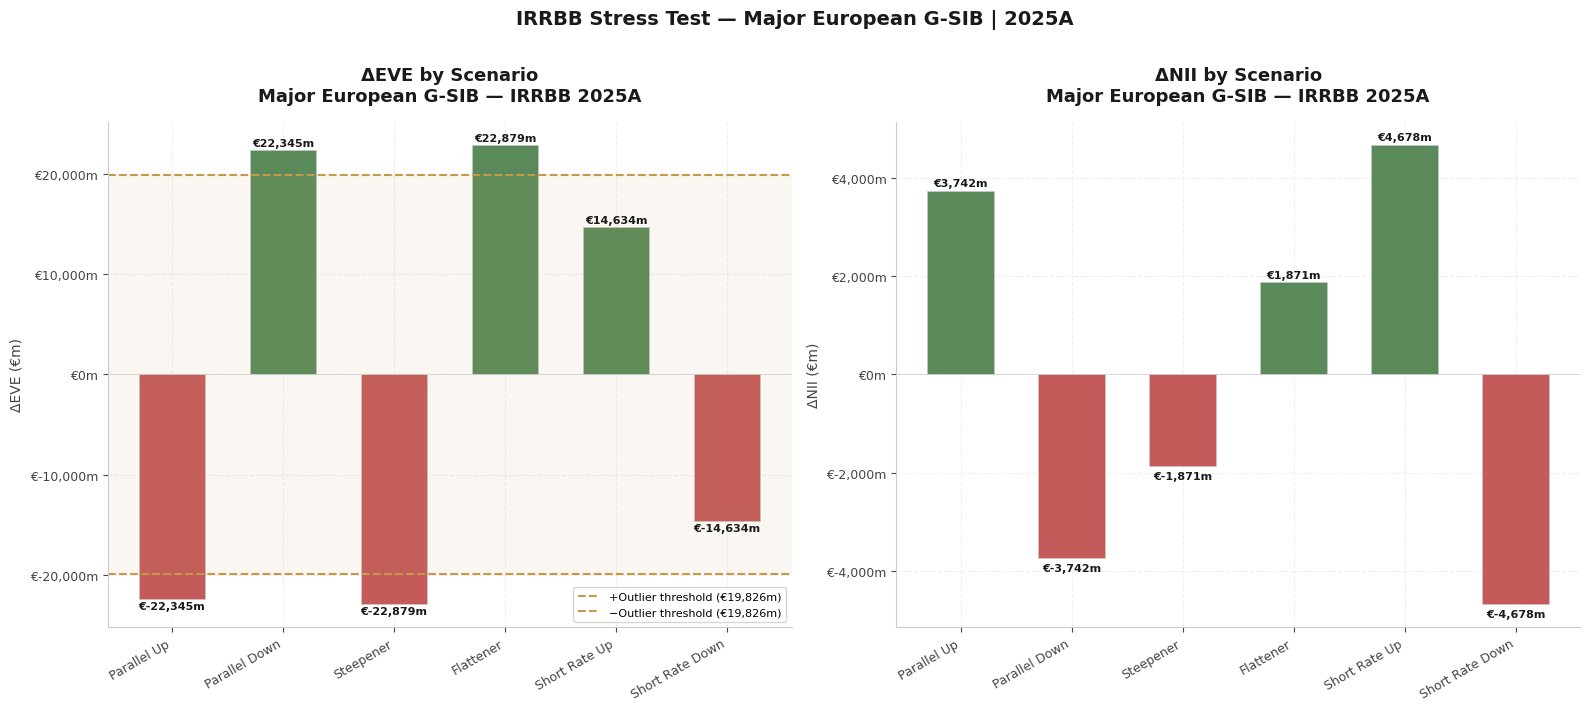

✅ Charts saved as IRRBB_charts.png


In [8]:
# ─────────────────────────────────────────────────────────────
# Cell 9 — Professional IRRBB Charts
# ─────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

scenario_labels = results_df['Scenario'].tolist()
eve_values      = results_df['ΔEVE (€m)'].tolist()
nii_values      = results_df['ΔNII (€m)'].tolist()
x               = range(len(scenario_labels))

# Colour logic: negative = muted red, positive = muted green
eve_colours = ['#c45a5a' if v < 0 else '#5a8a5a' for v in eve_values]
nii_colours = ['#c45a5a' if v < 0 else '#5a8a5a' for v in nii_values]

# ── CHART 1: ΔEVE ─────────────────────────────────────────────────────────────
ax1.set_facecolor('white')
bars1 = ax1.bar(x, eve_values, color=eve_colours,
                width=0.6, edgecolor='#cccccc', linewidth=0.4)

ax1.axhline(y= outlier_threshold, color='#c49a4a',
            linestyle='--', linewidth=1.5,
            label=f'+Outlier threshold (€{outlier_threshold:,.0f}m)')
ax1.axhline(y=-outlier_threshold, color='#c49a4a',
            linestyle='--', linewidth=1.5,
            label=f'−Outlier threshold (€{outlier_threshold:,.0f}m)')
ax1.axhline(y=0, color='#cccccc', linestyle='-', linewidth=0.5)

for bar, val in zip(bars1, eve_values):
    ypos = bar.get_height() + 200 if val >= 0 else bar.get_height() - 1200
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'€{val:,.0f}m', ha='center', va='bottom',
             color='#1a1a1a', fontsize=8, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(scenario_labels, rotation=30, ha='right', fontsize=9)
ax1.set_title('ΔEVE by Scenario\nMajor European G-SIB — IRRBB 2025A',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=15)
ax1.set_ylabel('ΔEVE (€m)', fontsize=10, color='#444444')
ax1.tick_params(colors='#444444', labelsize=9)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda val, _: f'€{val:,.0f}m'))
ax1.legend(fontsize=8, loc='lower right')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.axhspan(-outlier_threshold, outlier_threshold,
            alpha=0.07, color='#c49a4a')

# ── CHART 2: ΔNII ─────────────────────────────────────────────────────────────
ax2.set_facecolor('white')
bars2 = ax2.bar(x, nii_values, color=nii_colours,
                width=0.6, edgecolor='#cccccc', linewidth=0.4)
ax2.axhline(y=0, color='#cccccc', linestyle='-', linewidth=0.5)

for bar, val in zip(bars2, nii_values):
    ypos = bar.get_height() + 50 if val >= 0 else bar.get_height() - 300
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'€{val:,.0f}m', ha='center', va='bottom',
             color='#1a1a1a', fontsize=8, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(scenario_labels, rotation=30, ha='right', fontsize=9)
ax2.set_title('ΔNII by Scenario\nMajor European G-SIB — IRRBB 2025A',
              fontsize=13, fontweight='bold', color='#1a1a1a', pad=15)
ax2.set_ylabel('ΔNII (€m)', fontsize=10, color='#444444')
ax2.tick_params(colors='#444444', labelsize=9)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(
    lambda val, _: f'€{val:,.0f}m'))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.grid(True, alpha=0.3, color='#cccccc', linestyle='--', linewidth=0.8)
ax2.set_axisbelow(True)

plt.suptitle('IRRBB Stress Test — Major European G-SIB | 2025A',
             fontsize=14, fontweight='bold', color='#1a1a1a', y=1.01)
plt.tight_layout()
plt.savefig('IRRBB_charts.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Charts saved as IRRBB_charts.png")